# app

09 - ResNet18 Input Size CPU Study

Исследование влияния размера входного изображения на качество и скорость ResNet18.

Цель ноутбука:

1. Обучить ResNet18 на ROI-кадрах с размерами входа 128×128, 96×96 и 64×64.
2. Сравнить качество классификации стадий пайки.
3. Проверить, сохраняется ли качество определения `active_brazing`.
4. Подготовить модели для CPU latency benchmark.
5. Сформировать таблицу качества и скорости для выбора CPU-friendly конфигурации.

Базовый reference:

- ResNet18 224×224 — лучшее качество, но CPU-инференс медленный.
- MobileNetV3 Small 224×224 — CPU-friendly модель, p95 < 50 мс.
- ResNet18 64×64 — уже показал CPU latency < 50 мс, но требует проверки качества.

## bootstrap

In [1]:
import os
from pathlib import Path

def is_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False
    

IN_COLAB = is_colab()

if IN_COLAB:
    REPO_ROOT = Path("/content") / "BrazingSense"
else:
    REPO_ROOT = Path.cwd().resolve()

if not (REPO_ROOT / ".git").exists():
    raise RuntimeError(f"REPO_ROOT не похож на корень репозитория: {REPO_ROOT}")

os.chdir(REPO_ROOT)

## packages

In [2]:
from pathlib import Path
import json
import time
import random
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

## env

In [3]:
FPS = 10
ROOT = Path()
DRIVE_FOLDER = Path('/content/drive/MyDrive/Colab Notebooks/Diploma')
EXPERIMENT_NAME = "resnet_input_size_cpu"

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

In [33]:
DATA = ROOT / "data" 
SPLITS_DIR = DATA / "annotations" / f"splits_{FPS}"
TRAIN_PATH = SPLITS_DIR / "train.csv"
VAL_PATH = SPLITS_DIR / "val.csv"
TEST_PATH = SPLITS_DIR / "test.csv"

DATA_PROCESSED = DATA / 'processed'
DATA_PROCESSED_FRAMES = DATA_PROCESSED / f'frames_{FPS}'
DRIVE_PROCESSED_FRAMES_FOLDER = DRIVE_FOLDER / DATA_PROCESSED_FRAMES

DATA_RAW = DATA / 'raw'
DRIVE_DATA_RAW = DRIVE_FOLDER / DATA_RAW

assert TRAIN_PATH.exists(), TRAIN_PATH
assert VAL_PATH.exists(), VAL_PATH
assert TEST_PATH.exists(), TEST_PATH

In [34]:
MODELS_DIR = ROOT / "models"
CHECKPOINTS_DIR = MODELS_DIR / "checkpoints" / EXPERIMENT_NAME
DRIVE_CHECKPOINTS_DIR = DRIVE_FOLDER / CHECKPOINTS_DIR


CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
REPORTS_ROOT = ROOT / "reports"
FIGURES_ROOT = ROOT / "reports" / "figures"
REPORTS_DIR = REPORTS_ROOT / EXPERIMENT_NAME
FIGURES_DIR = FIGURES_ROOT / EXPERIMENT_NAME

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [8]:
STAGE_ORDER = [
    "inactive_preparation",
    "flux_activation",
    "active_brazing",
    "stabilization",
]

STAGE_TO_ID = {
    "inactive_preparation": 0,
    "flux_activation": 1,
    "active_brazing": 2,
    "stabilization": 3,
}

ID_TO_STAGE = {v: k for k, v in STAGE_TO_ID.items()}

ROI = {
    "x": 470,
    "y": 280,
    "w": 430,
    "h": 290,
}

IMAGE_SIZES = [128, 96, 64]

ROI, IMAGE_SIZES

({'x': 470, 'y': 280, 'w': 430, 'h': 290}, [128, 96, 64])

# lib

In [9]:
def resolve_path(path_value: str) -> Path:
    path = Path(path_value)
    if path.is_absolute():
        return path
    return ROOT / path


def read_rgb_image(path: Path) -> np.ndarray:
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise ValueError(f"Could not read image: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def crop_roi(image: np.ndarray, roi: dict) -> np.ndarray:
    x, y, w, h = roi["x"], roi["y"], roi["w"], roi["h"]
    height, width = image.shape[:2]

    x1 = max(0, x)
    y1 = max(0, y)
    x2 = min(width, x + w)
    y2 = min(height, y + h)

    if x1 >= x2 or y1 >= y2:
        raise ValueError(f"Invalid ROI for image shape {image.shape}: {roi}")

    return image[y1:y2, x1:x2]

# model

In [10]:
class BrazingStageDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        roi: dict,
        transform=None,
    ):
        self.df = df.reset_index(drop=True).copy()
        self.roi = roi
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        image_path = resolve_path(row["frame_path"])
        image = read_rgb_image(image_path)
        image = crop_roi(image, self.roi)

        if self.transform is not None:
            image = self.transform(image)

        label = int(row["stage_id"])

        metadata = {
            "video_id": row["video_id"],
            "frame_path": row["frame_path"],
            "timestamp_s": float(row["timestamp_s"]),
            "stage_name": row["stage_name"],
        }

        return image, label, metadata

# runtime

## copy

In [11]:
import subprocess

if IN_COLAB:
    from google.colab import drive # type: ignore
    drive.mount("/content/drive")

    copy_frames = ["cp", "-r", "-v", f"{DRIVE_PROCESSED_FRAMES_FOLDER}/.", f"{DATA_PROCESSED_FRAMES}/"]
    with open("copy_frames.log", "w") as frames_log:
        copy_frames_process = subprocess.Popen(copy_frames, stdout=frames_log, stderr=subprocess.STDOUT, text=True)

    # copy_checkpoints = ["cp", "-r", "-v", f"{DRIVE_CHECKPOINTS_DIR}/.", f"{CHECKPOINTS_DIR}/"]
    # with open("copy_checkpoints.log", "w") as checkpoints_log:
    #     copy_checkpoints_process = subprocess.Popen(copy_checkpoints, stdout=checkpoints_log, stderr=subprocess.STDOUT, text=True)

    copy_raw_data = ["cp", "-r", "-v", f"{DRIVE_DATA_RAW}/.", f"{DATA_RAW}/"]
    with open("copy_raw_data.log", "w") as data_log:
        copy_raw_data_process = subprocess.Popen(copy_raw_data, stdout=data_log, stderr=subprocess.STDOUT, text=True)

    # !cp -r -v "$DRIVE_PROCESSED_FRAMES_FOLDER"/. "$DATA_PROCESSED_FRAMES"/

Mounted at /content/drive


In [90]:
print("Process", copy_frames_process.poll())
!tail copy_frames.log

Process 0
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/processed/frames_10/./MVI_6283/MVI_6283_000578_0057.800s.jpg' -> 'data/processed/frames_10/MVI_6283/MVI_6283_000578_0057.800s.jpg'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/processed/frames_10/./MVI_6283/MVI_6283_000579_0057.900s.jpg' -> 'data/processed/frames_10/MVI_6283/MVI_6283_000579_0057.900s.jpg'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/processed/frames_10/./MVI_6283/MVI_6283_000580_0058.000s.jpg' -> 'data/processed/frames_10/MVI_6283/MVI_6283_000580_0058.000s.jpg'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/processed/frames_10/./MVI_6283/MVI_6283_000581_0058.100s.jpg' -> 'data/processed/frames_10/MVI_6283/MVI_6283_000581_0058.100s.jpg'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/processed/frames_10/./MVI_6283/MVI_6283_000582_0058.200s.jpg' -> 'data/processed/frames_10/MVI_6283/MVI_6283_000582_0058.200s.jpg'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/processed/frames_

In [25]:
print("Process", copy_raw_data_process.poll())
!tail copy_raw_data.log

Process 0
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/raw/./MVI_6266.MOV' -> 'data/raw/./MVI_6266.MOV'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/raw/./MVI_6276.MOV' -> 'data/raw/./MVI_6276.MOV'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/raw/./MVI_6268.MOV' -> 'data/raw/./MVI_6268.MOV'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/raw/./MVI_6269.MOV' -> 'data/raw/./MVI_6269.MOV'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/raw/./MVI_6270.MOV' -> 'data/raw/./MVI_6270.MOV'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/raw/./MVI_6271.MOV' -> 'data/raw/./MVI_6271.MOV'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/raw/./MVI_6272.MOV' -> 'data/raw/./MVI_6272.MOV'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/raw/./MVI_6273.MOV' -> 'data/raw/./MVI_6273.MOV'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/raw/./MVI_6274.MOV' -> 'data/raw/./MVI_6274.MOV'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/raw/./MVI_6275.MOV'

## prepare

### load splits

In [11]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

train_df.head()

train: (5755, 8)
val: (1091, 8)
test: (1732, 8)


,video_id,video_path,frame_path,timestamp_s,stage_id,stage_name,source_fps,target_fps
0,MVI_6268,data/raw/MVI_6268.MOV,data/processed/frames_10/MVI_6268/MVI_6268_000...,0.0,0,inactive_preparation,29.97003,10.0
1,MVI_6268,data/raw/MVI_6268.MOV,data/processed/frames_10/MVI_6268/MVI_6268_000...,0.1,0,inactive_preparation,29.97003,10.0
2,MVI_6268,data/raw/MVI_6268.MOV,data/processed/frames_10/MVI_6268/MVI_6268_000...,0.2,0,inactive_preparation,29.97003,10.0
3,MVI_6268,data/raw/MVI_6268.MOV,data/processed/frames_10/MVI_6268/MVI_6268_000...,0.3,0,inactive_preparation,29.97003,10.0
4,MVI_6268,data/raw/MVI_6268.MOV,data/processed/frames_10/MVI_6268/MVI_6268_000...,0.4,0,inactive_preparation,29.97003,10.0


In [12]:
def stage_counts(df):
    return df.groupby("stage_name").size().reindex(STAGE_ORDER).fillna(0).astype(int)

split_counts = pd.DataFrame({
    "train": stage_counts(train_df),
    "val": stage_counts(val_df),
    "test": stage_counts(test_df),
})

split_counts

,train,val,test
stage_name,,,
inactive_preparation,3552,734,1000
flux_activation,506,102,138
active_brazing,766,138,196
stabilization,931,117,398


### transforms

In [13]:
def make_transforms(image_size: int):
    train_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((image_size, image_size)),
        transforms.RandomApply([
            transforms.ColorJitter(
                brightness=0.12,
                contrast=0.12,
                saturation=0.08,
                hue=0.02,
            )
        ], p=0.6),
        transforms.RandomApply([
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8))
        ], p=0.15),
        transforms.RandomRotation(degrees=2),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

    eval_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

    return train_transform, eval_transform

### dataloader

In [14]:
BATCH_SIZE = 32
NUM_WORKERS = 2

def make_dataloaders(image_size: int):
    train_transform, eval_transform = make_transforms(image_size)

    train_dataset = BrazingStageDataset(
        train_df,
        roi=ROI,
        transform=train_transform,
    )

    val_dataset = BrazingStageDataset(
        val_df,
        roi=ROI,
        transform=eval_transform,
    )

    test_dataset = BrazingStageDataset(
        test_df,
        roi=ROI,
        transform=eval_transform,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    return train_loader, val_loader, test_loader

### visual check

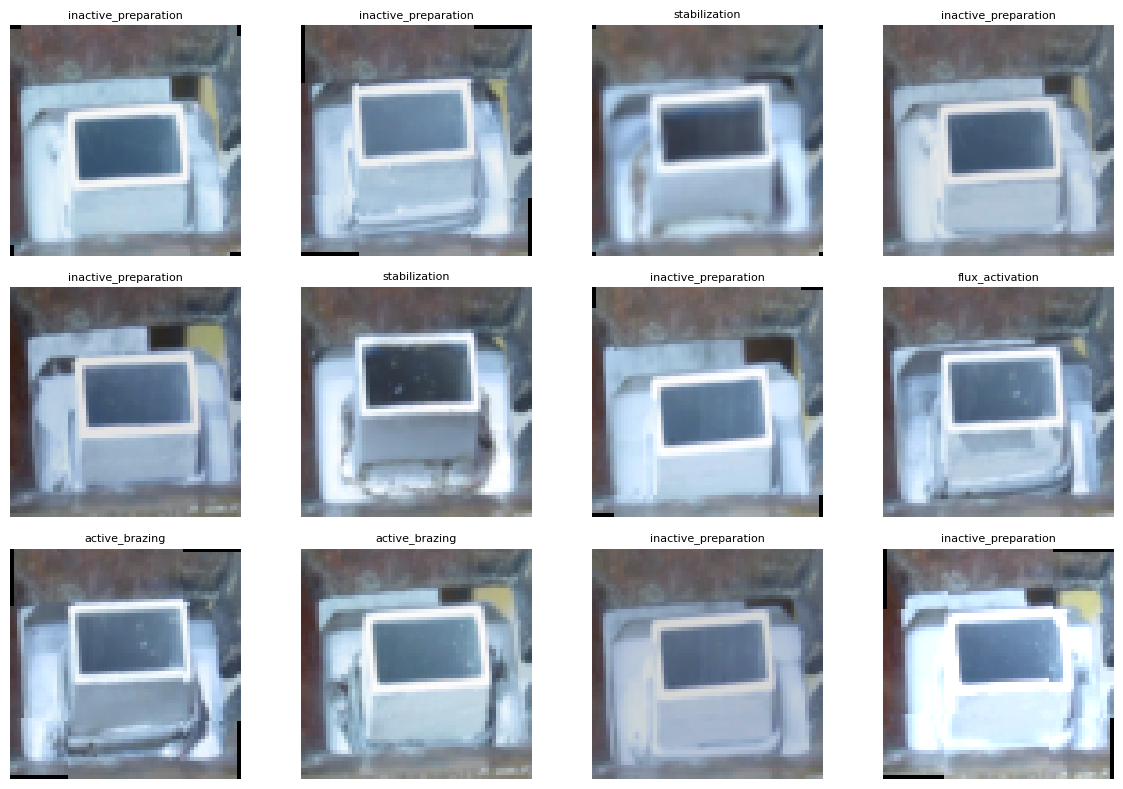

In [15]:
def denormalize_tensor(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image = image_tensor.cpu() * std + mean
    image = image.clamp(0, 1)
    return image.permute(1, 2, 0).numpy()


tmp_train_loader, _, _ = make_dataloaders(image_size=64)
images, labels, metadata = next(iter(tmp_train_loader))

plt.figure(figsize=(12, 8))

for i in range(min(12, len(images))):
    plt.subplot(3, 4, i + 1)
    plt.imshow(denormalize_tensor(images[i]))
    plt.axis("off")
    plt.title(ID_TO_STAGE[int(labels[i])], fontsize=8)

plt.tight_layout()
plt.show()

### class weights

In [16]:
def make_class_weights(train_df: pd.DataFrame):
    train_counts = train_df["stage_id"].value_counts().sort_index()
    train_counts = train_counts.reindex([0, 1, 2, 3]).fillna(0).astype(int)

    total = train_counts.sum()
    num_classes = len(train_counts)

    weights = total / (num_classes * train_counts.values)
    weights = weights.astype(np.float32)

    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


class_weights = make_class_weights(train_df)
class_weights

tensor([0.4051, 2.8434, 1.8783, 1.5454], device='cuda:0')

### model factory

In [17]:
def create_resnet18(num_classes: int = 4, pretrained: bool = True):
    weights = models.ResNet18_Weights.DEFAULT if pretrained else None
    model = models.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

### predict / evaluate helpers

In [18]:
def predict_loader(model, loader, device=DEVICE):
    model.eval()

    all_probs = []
    all_preds = []
    all_targets = []
    all_metadata = []

    with torch.no_grad():
        for images, labels, metadata in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_targets.extend(labels.cpu().numpy().tolist())

            batch_size = len(labels)
            for i in range(batch_size):
                all_metadata.append({
                    "video_id": metadata["video_id"][i],
                    "frame_path": metadata["frame_path"][i],
                    "timestamp_s": float(metadata["timestamp_s"][i]),
                    "stage_name": metadata["stage_name"][i],
                })

    probs_np = torch.cat(all_probs, dim=0).numpy()

    pred_df = pd.DataFrame(all_metadata)
    pred_df["stage_id"] = all_targets
    pred_df["pred_stage_id"] = all_preds
    pred_df["pred_stage_name"] = pred_df["pred_stage_id"].map(ID_TO_STAGE)

    for class_id, stage_name in ID_TO_STAGE.items():
        pred_df[f"prob_{stage_name}"] = probs_np[:, class_id]

    return pred_df


def evaluate_predictions(pred_df: pd.DataFrame, title: str):
    y_true = pred_df["stage_id"].to_numpy()
    y_pred = pred_df["pred_stage_id"].to_numpy()

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(title)
    print("-" * 80)
    print(f"accuracy:    {acc:.4f}")
    print(f"macro_f1:    {macro_f1:.4f}")
    print(f"weighted_f1: {weighted_f1:.4f}")
    print()

    print(classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2, 3],
        target_names=STAGE_ORDER,
        digits=4,
        zero_division=0,
    ))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=STAGE_ORDER,
    )

    fig, ax = plt.subplots(figsize=(8, 7))
    disp.plot(ax=ax, xticks_rotation=30, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2, 3],
        target_names=STAGE_ORDER,
        output_dict=True,
        zero_division=0,
    )

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "active_brazing_precision": report["active_brazing"]["precision"],
        "active_brazing_recall": report["active_brazing"]["recall"],
        "active_brazing_f1": report["active_brazing"]["f1-score"],
        "confusion_matrix": cm.tolist(),
    }

### train helpers

In [19]:
def run_one_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    device=DEVICE,
):
    is_train = optimizer is not None

    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_targets = []
    all_preds = []

    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)

        all_targets.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")
    weighted_f1 = f1_score(all_targets, all_preds, average="weighted")

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }


def train_resnet_for_size(
    image_size: int,
    epochs: int = 15,
    lr: float = 3e-4,
    weight_decay: float = 1e-4,
):
    run_name = f"resnet18_{image_size}"

    train_loader, val_loader, test_loader = make_dataloaders(image_size)

    model = create_resnet18(num_classes=4, pretrained=True).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=4,
    )

    best_val_macro_f1 = -1.0
    best_state = None
    history = []

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        train_metrics = run_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
            device=DEVICE,
        )

        val_metrics = run_one_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None,
            device=DEVICE,
        )

        # per-class active_brazing val metrics
        val_pred_df = predict_loader(model, val_loader)
        y_val_true = val_pred_df["stage_id"].to_numpy()
        y_val_pred = val_pred_df["pred_stage_id"].to_numpy()

        val_report = classification_report(
            y_val_true,
            y_val_pred,
            labels=[0, 1, 2, 3],
            target_names=STAGE_ORDER,
            output_dict=True,
            zero_division=0,
        )

        val_active_f1 = val_report["active_brazing"]["f1-score"]
        val_active_recall = val_report["active_brazing"]["recall"]

        scheduler.step(val_metrics["macro_f1"])

        epoch_time = time.time() - start_time

        row = {
            "epoch": epoch,
            "run_name": run_name,
            "image_size": image_size,
            "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_s": epoch_time,
            "val_active_brazing_f1": val_active_f1,
            "val_active_brazing_recall": val_active_recall,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }

        history.append(row)

        print(
            f"[{run_name}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_f1={train_metrics['macro_f1']:.4f} | "
            f"val_f1={val_metrics['macro_f1']:.4f} "
            f"val_acc={val_metrics['accuracy']:.4f} "
            f"val_active_f1={val_active_f1:.4f} "
            f"val_active_recall={val_active_recall:.4f} | "
            f"{epoch_time:.1f}s"
        )

        if val_metrics["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_state = {
                "run_name": run_name,
                "model_name": "resnet18",
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "val_macro_f1": best_val_macro_f1,
                "val_active_brazing_f1": val_active_f1,
                "val_active_brazing_recall": val_active_recall,
                "roi": ROI,
                "image_size": image_size,
                "stage_order": STAGE_ORDER,
                "fps": FPS,
            }

    history_df = pd.DataFrame(history)

    checkpoint_path = CHECKPOINTS_DIR / f"{run_name}_best.pt"
    torch.save(best_state, checkpoint_path)

    history_path = REPORTS_DIR / f"{run_name}_history.csv"
    history_df.to_csv(history_path, index=False)

    model.load_state_dict(best_state["model_state_dict"])

    return model, history_df, checkpoint_path, test_loader

## train resnet

In [20]:
EXPERIMENTS = {}

for image_size in IMAGE_SIZES:
    model, history_df, checkpoint_path, test_loader = train_resnet_for_size(
        image_size=image_size,
        epochs=16,
        lr=3e-4,
        weight_decay=1e-4,
    )

    EXPERIMENTS[image_size] = {
        "model": model,
        "history": history_df,
        "checkpoint": checkpoint_path,
        "test_loader": test_loader,
    }

[resnet18_128] Epoch 01/16 | train_f1=0.8564 | val_f1=0.6726 val_acc=0.7938 val_active_f1=0.6482 val_active_recall=0.8478 | 18.7s
[resnet18_128] Epoch 02/16 | train_f1=0.9386 | val_f1=0.6724 val_acc=0.7058 val_active_f1=0.7105 val_active_recall=0.7826 | 18.4s
[resnet18_128] Epoch 03/16 | train_f1=0.9575 | val_f1=0.7983 val_acc=0.9019 val_active_f1=0.7176 val_active_recall=0.7826 | 18.2s
[resnet18_128] Epoch 04/16 | train_f1=0.9630 | val_f1=0.6367 val_acc=0.8029 val_active_f1=0.6091 val_active_recall=0.9710 | 18.3s
[resnet18_128] Epoch 05/16 | train_f1=0.9646 | val_f1=0.7807 val_acc=0.8983 val_active_f1=0.7034 val_active_recall=0.7391 | 18.1s
[resnet18_128] Epoch 06/16 | train_f1=0.9776 | val_f1=0.7478 val_acc=0.7883 val_active_f1=0.7481 val_active_recall=0.7319 | 18.1s
[resnet18_128] Epoch 07/16 | train_f1=0.9771 | val_f1=0.7015 val_acc=0.8350 val_active_f1=0.6505 val_active_recall=0.7754 | 18.4s
[resnet18_128] Epoch 08/16 | train_f1=0.9770 | val_f1=0.8089 val_acc=0.9083 val_active_f1=

### curves

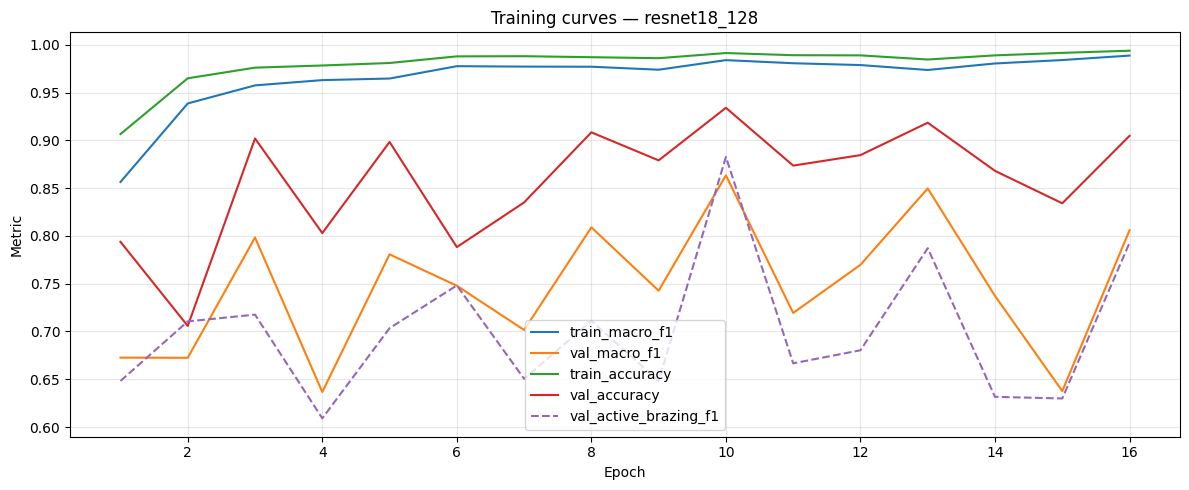

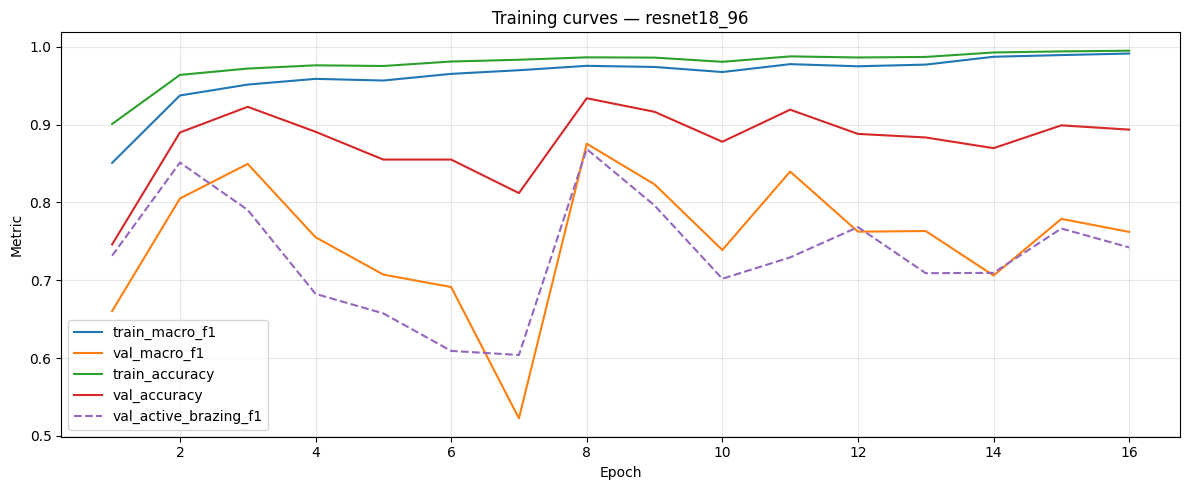

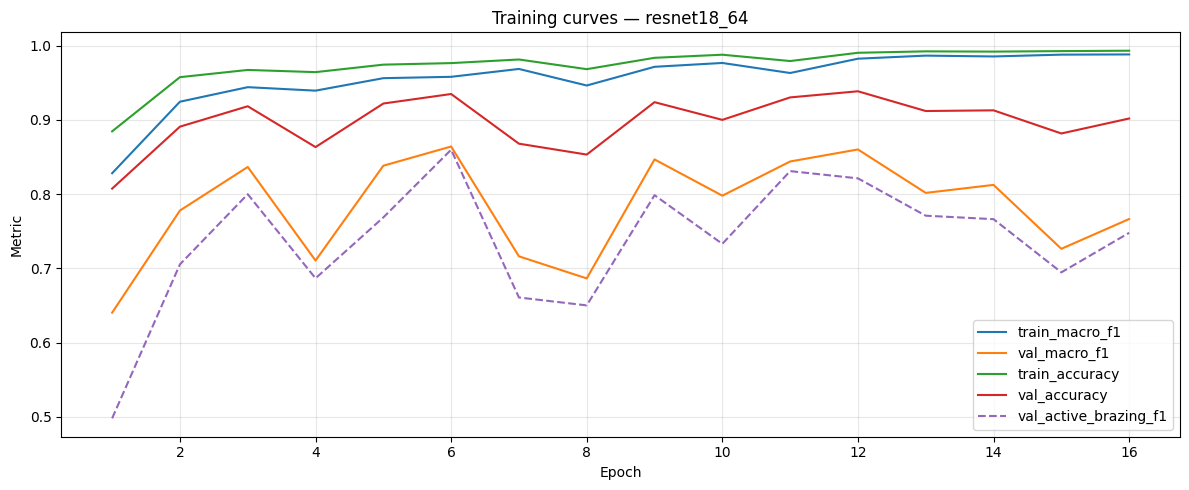

In [41]:
def plot_history(history_df, run_name):
    plt.figure(figsize=(12, 5))

    plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="train_macro_f1")
    plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="val_macro_f1")
    plt.plot(history_df["epoch"], history_df["train_accuracy"], label="train_accuracy")
    plt.plot(history_df["epoch"], history_df["val_accuracy"], label="val_accuracy")

    if "val_active_brazing_f1" in history_df.columns:
        plt.plot(
            history_df["epoch"],
            history_df["val_active_brazing_f1"],
            label="val_active_brazing_f1",
            linestyle="--",
        )

    plt.title(f"Training curves — {run_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_path = FIGURES_DIR / f"{run_name}_training_curves.png"
    plt.savefig(output_path, dpi=160)
    plt.show()


for image_size, exp in EXPERIMENTS.items():
    plot_history(exp["history"], f"resnet18_{image_size}")

### comparison

In [22]:
validation_rows = []

for image_size, exp in EXPERIMENTS.items():
    history_df = exp["history"]
    best_row = history_df.loc[history_df["val_macro_f1"].idxmax()]

    validation_rows.append({
        "model": "resnet18",
        "image_size": image_size,
        "best_val_macro_f1": best_row["val_macro_f1"],
        "best_val_accuracy": best_row["val_accuracy"],
        "best_val_active_brazing_f1": best_row["val_active_brazing_f1"],
        "best_val_active_brazing_recall": best_row["val_active_brazing_recall"],
        "checkpoint": str(exp["checkpoint"]),
    })

validation_comparison_df = pd.DataFrame(validation_rows).sort_values(
    "best_val_macro_f1",
    ascending=False,
)

validation_comparison_df

,model,image_size,best_val_macro_f1,best_val_accuracy,best_val_active_brazing_f1,best_val_active_brazing_recall,checkpoint
1,resnet18,96,0.875587,0.934005,0.868687,0.934783,models/checkpoints/resnet_input_size_cpu/resne...
2,resnet18,64,0.864217,0.934922,0.859873,0.978261,models/checkpoints/resnet_input_size_cpu/resne...
0,resnet18,128,0.863339,0.934005,0.882562,0.898551,models/checkpoints/resnet_input_size_cpu/resne...


In [23]:
validation_comparison_df.to_csv(
    REPORTS_DIR / "resnet_input_size_validation_comparison.csv",
    index=False,
)

### test evaluation

Test — ResNet18 128x128
--------------------------------------------------------------------------------
accuracy:    0.8331
macro_f1:    0.7559
weighted_f1: 0.8500

                      precision    recall  f1-score   support

inactive_preparation     0.9988    0.8060    0.8921      1000
     flux_activation     0.3838    0.9928    0.5535       138
      active_brazing     0.7241    0.5357    0.6158       196
       stabilization     0.9338    0.9925    0.9622       398

            accuracy                         0.8331      1732
           macro avg     0.7601    0.8317    0.7559      1732
        weighted avg     0.9038    0.8331    0.8500      1732



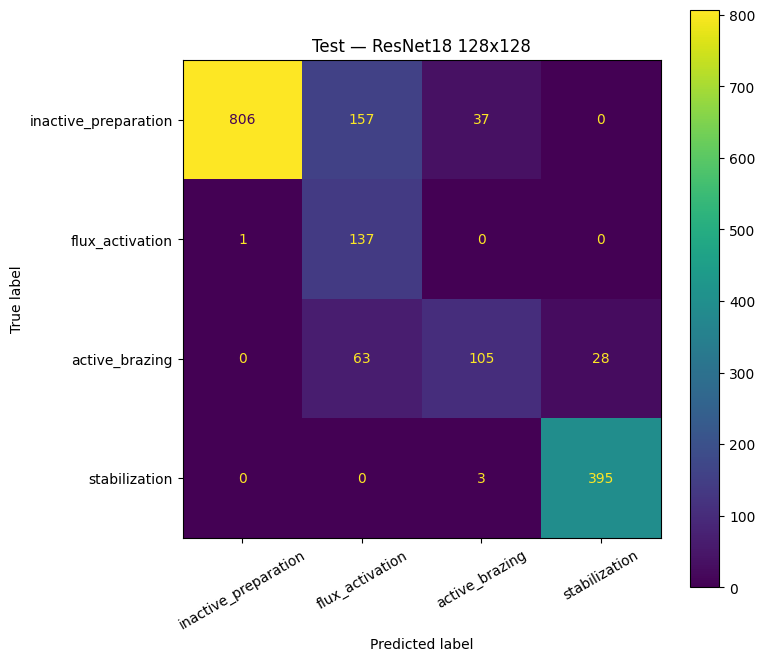

Test — ResNet18 96x96
--------------------------------------------------------------------------------
accuracy:    0.8580
macro_f1:    0.7739
weighted_f1: 0.8714

                      precision    recall  f1-score   support

inactive_preparation     0.9977    0.8810    0.9357      1000
     flux_activation     0.4334    0.9203    0.5893       138
      active_brazing     0.7035    0.6173    0.6576       196
       stabilization     0.9297    0.8970    0.9130       398

            accuracy                         0.8580      1732
           macro avg     0.7661    0.8289    0.7739      1732
        weighted avg     0.9038    0.8580    0.8714      1732



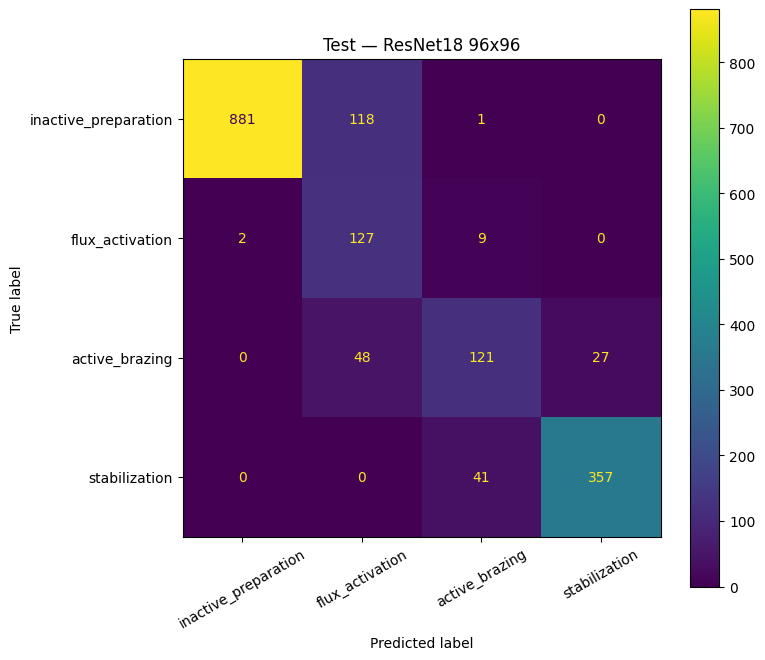

Test — ResNet18 64x64
--------------------------------------------------------------------------------
accuracy:    0.8990
macro_f1:    0.7967
weighted_f1: 0.9033

                      precision    recall  f1-score   support

inactive_preparation     0.9979    0.9550    0.9760      1000
     flux_activation     0.5047    0.7826    0.6136       138
      active_brazing     0.7372    0.5867    0.6534       196
       stabilization     0.9358    0.9523    0.9440       398

            accuracy                         0.8990      1732
           macro avg     0.7939    0.8192    0.7967      1732
        weighted avg     0.9148    0.8990    0.9033      1732



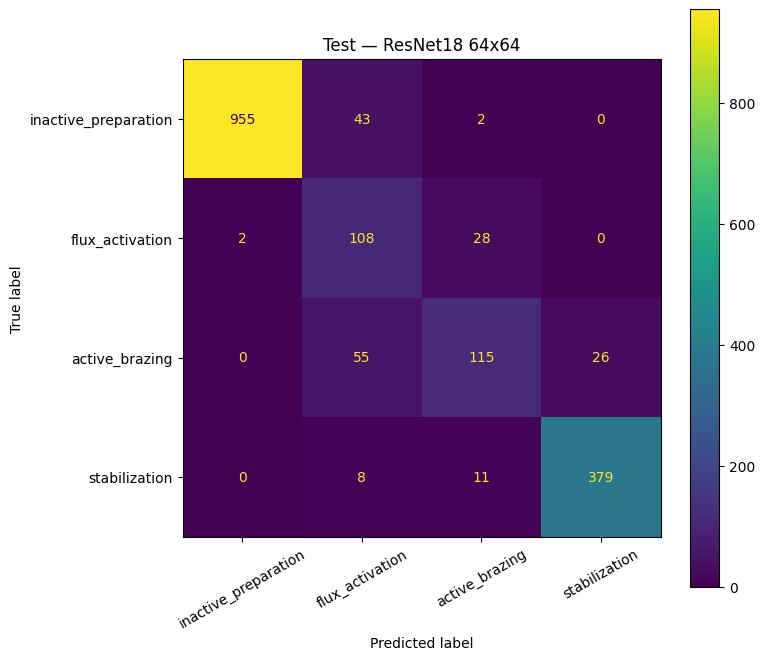

,model,image_size,accuracy,macro_f1,weighted_f1,active_brazing_precision,active_brazing_recall,active_brazing_f1,checkpoint
2,resnet18,64,0.898961,0.796747,0.903250,0.737179,0.586735,0.653409,models/checkpoints/resnet_input_size_cpu/resne...
1,resnet18,96,0.857968,0.773930,0.871450,0.703488,0.617347,0.657609,models/checkpoints/resnet_input_size_cpu/resne...
0,resnet18,128,0.833141,0.755925,0.849971,0.724138,0.535714,0.615836,models/checkpoints/resnet_input_size_cpu/resne...


In [24]:
test_rows = []
test_predictions = {}

for image_size, exp in EXPERIMENTS.items():
    model = exp["model"]
    test_loader = exp["test_loader"]

    pred_df = predict_loader(model, test_loader)

    metrics = evaluate_predictions(
        pred_df,
        title=f"Test — ResNet18 {image_size}x{image_size}",
    )

    test_predictions[image_size] = pred_df

    pred_df.to_csv(
        REPORTS_DIR / f"resnet18_{image_size}_test_predictions.csv",
        index=False,
    )

    test_rows.append({
        "model": "resnet18",
        "image_size": image_size,
        **{k: v for k, v in metrics.items() if k != "confusion_matrix"},
        "checkpoint": str(exp["checkpoint"]),
    })

test_comparison_df = pd.DataFrame(test_rows).sort_values(
    "macro_f1",
    ascending=False,
)

test_comparison_df

In [25]:
test_comparison_df.to_csv(
    REPORTS_DIR / "resnet_input_size_test_comparison.csv",
    index=False,
)

### error pairs

In [26]:
def get_error_pairs(pred_df: pd.DataFrame):
    errors_df = pred_df[pred_df["stage_id"] != pred_df["pred_stage_id"]].copy()

    return (
        errors_df
        .groupby(["stage_name", "pred_stage_name"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )


for image_size, pred_df in test_predictions.items():
    print(f"Error pairs — ResNet18 {image_size}")
    display(get_error_pairs(pred_df).head(20))

Error pairs — ResNet18 128


,stage_name,pred_stage_name,count
4,inactive_preparation,flux_activation,157
0,active_brazing,flux_activation,63
3,inactive_preparation,active_brazing,37
1,active_brazing,stabilization,28
5,stabilization,active_brazing,3
2,flux_activation,inactive_preparation,1


Error pairs — ResNet18 96


,stage_name,pred_stage_name,count
5,inactive_preparation,flux_activation,118
0,active_brazing,flux_activation,48
6,stabilization,active_brazing,41
1,active_brazing,stabilization,27
2,flux_activation,active_brazing,9
3,flux_activation,inactive_preparation,2
4,inactive_preparation,active_brazing,1


Error pairs — ResNet18 64


,stage_name,pred_stage_name,count
0,active_brazing,flux_activation,55
5,inactive_preparation,flux_activation,43
2,flux_activation,active_brazing,28
1,active_brazing,stabilization,26
6,stabilization,active_brazing,11
7,stabilization,flux_activation,8
3,flux_activation,inactive_preparation,2
4,inactive_preparation,active_brazing,2


### timeline

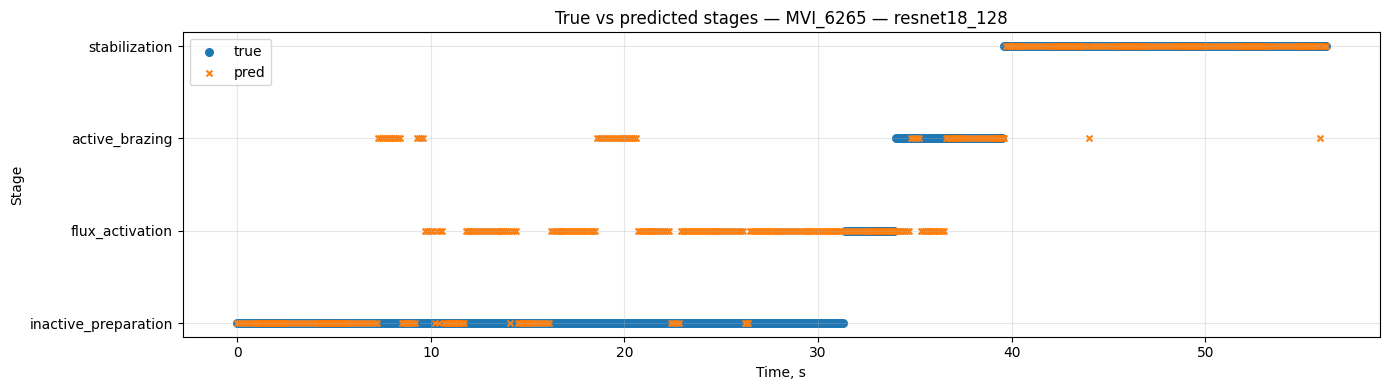

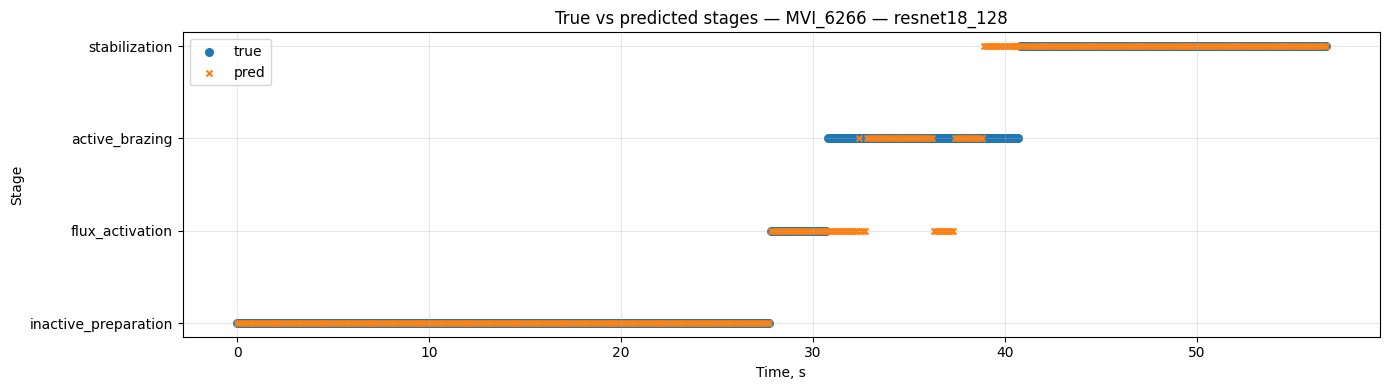

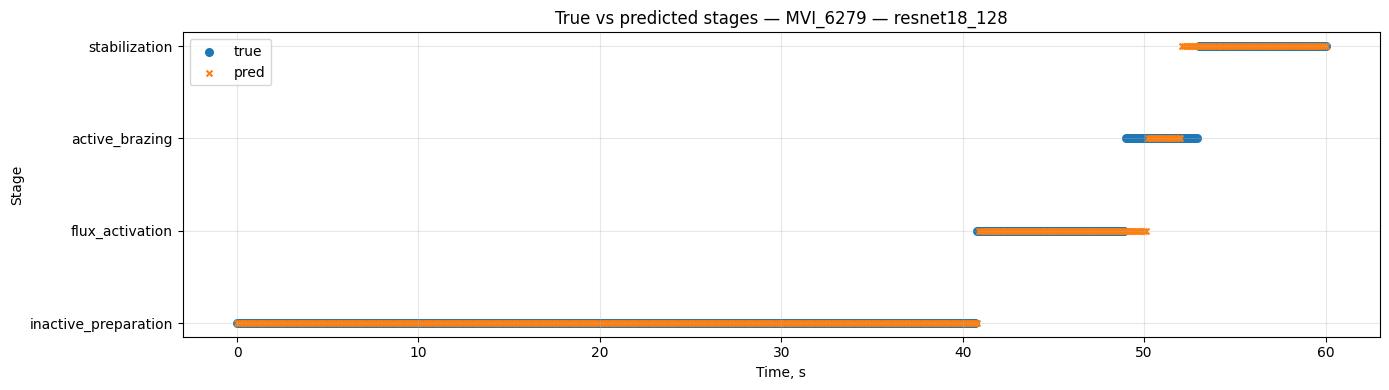

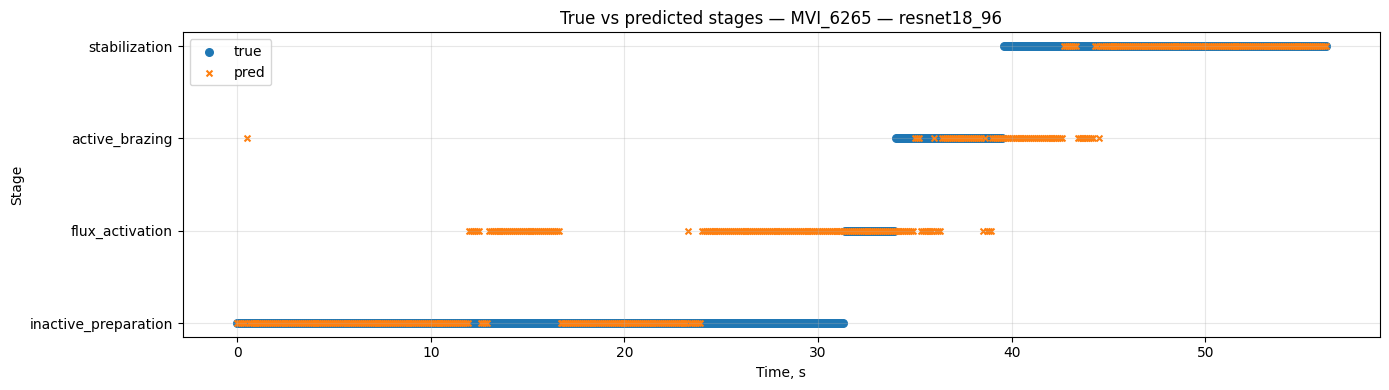

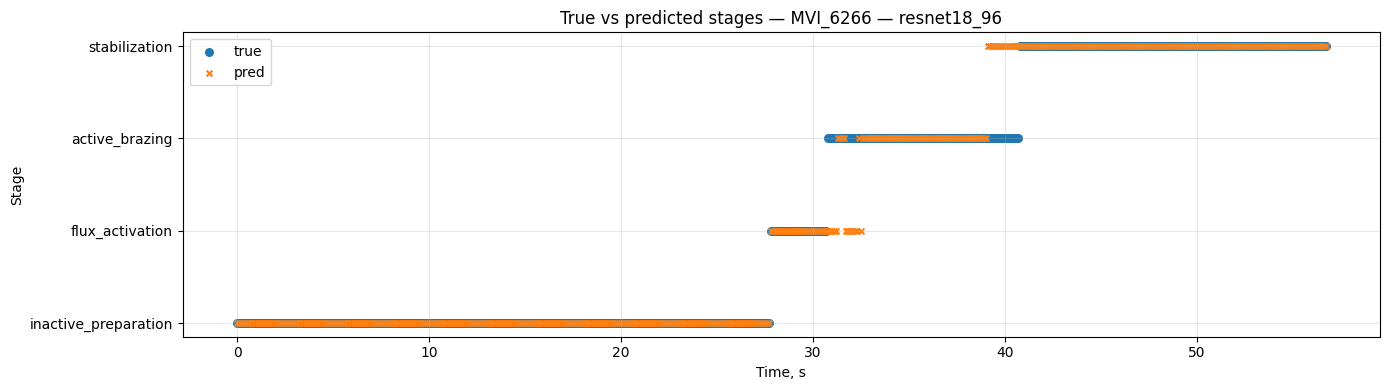

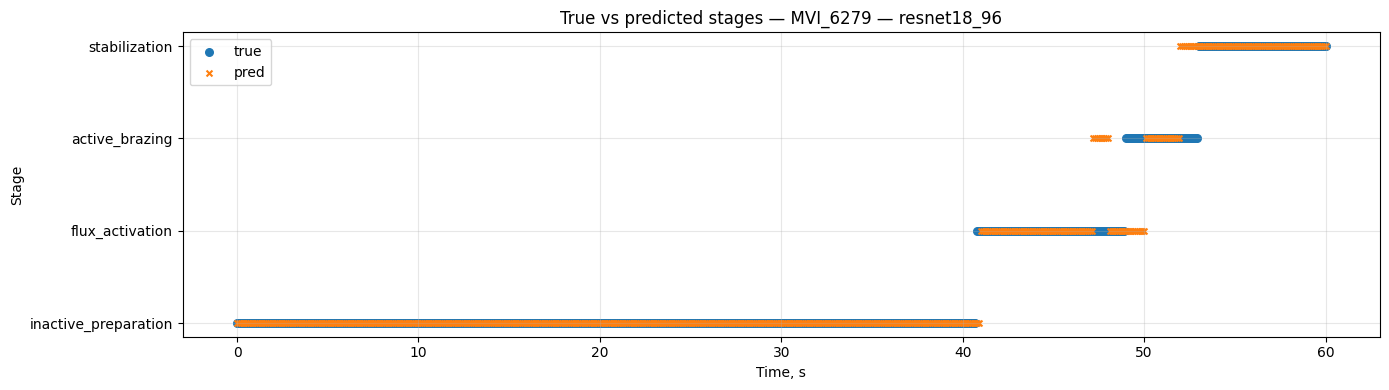

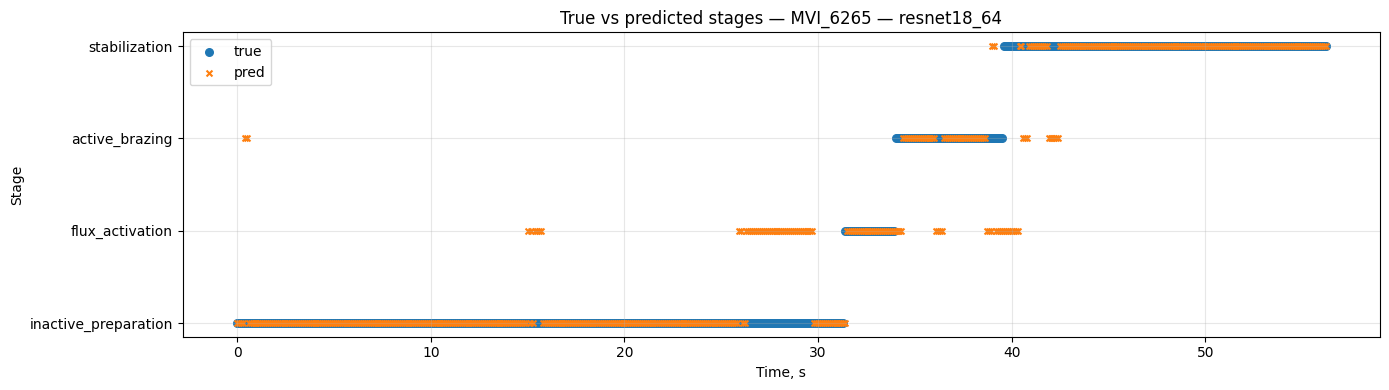

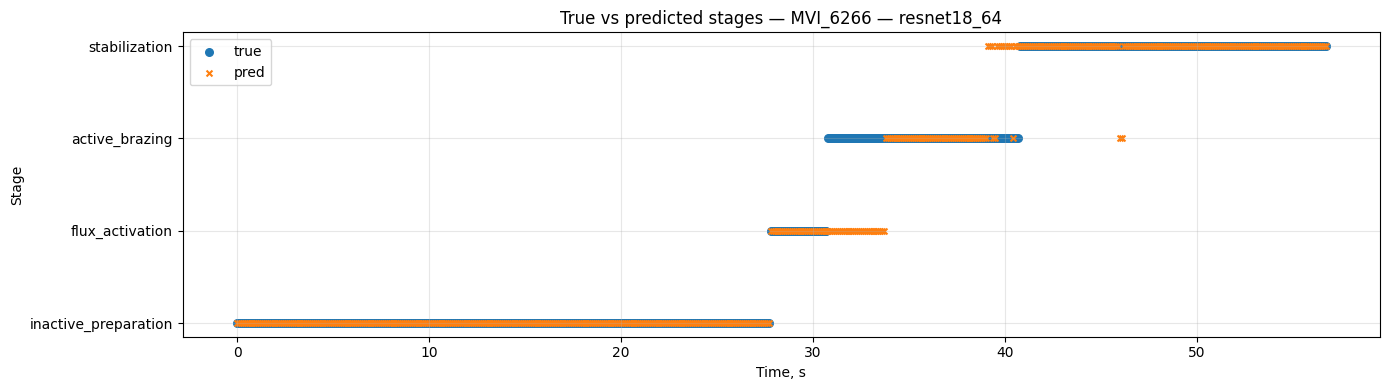

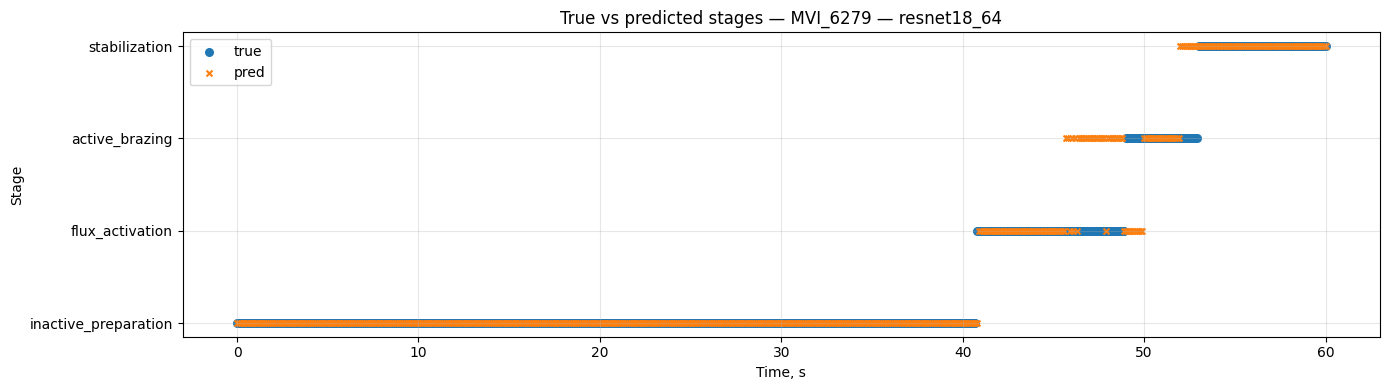

In [27]:
def plot_predictions_for_video(pred_df: pd.DataFrame, video_id: str, run_name: str):
    video_df = pred_df[pred_df["video_id"] == video_id].sort_values("timestamp_s")

    if len(video_df) == 0:
        print(f"No rows for {video_id}")
        return

    plt.figure(figsize=(14, 4))

    plt.scatter(
        video_df["timestamp_s"],
        video_df["stage_id"],
        s=30,
        label="true",
        marker="o",
    )

    plt.scatter(
        video_df["timestamp_s"],
        video_df["pred_stage_id"],
        s=18,
        label="pred",
        marker="x",
    )

    plt.yticks([0, 1, 2, 3], STAGE_ORDER)
    plt.xlabel("Time, s")
    plt.ylabel("Stage")
    plt.title(f"True vs predicted stages — {video_id} — {run_name}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_path = FIGURES_DIR / f"{video_id}_{run_name}_timeline.png"
    plt.savefig(output_path, dpi=160)
    plt.show()


for image_size, pred_df in test_predictions.items():
    for video_id in sorted(pred_df["video_id"].unique()):
        plot_predictions_for_video(
            pred_df,
            video_id=video_id,
            run_name=f"resnet18_{image_size}",
        )

## fine_tune_resnet_experiment

In [37]:
def fine_tune_resnet_experiment(
    image_size: int,
    experiment: dict,
    extra_epochs: int = 8,
    lr: float = 1e-4,
    weight_decay: float = 1e-4,
    active_brazing_boost: float = 1.0,
):
    run_name = f"resnet18_{image_size}_finetuned"

    model = experiment["model"].to(DEVICE)

    train_loader, val_loader, test_loader = make_dataloaders(image_size)

    fine_tune_weights = class_weights.clone()
    fine_tune_weights[2] *= active_brazing_boost

    criterion = nn.CrossEntropyLoss(weight=fine_tune_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3,
    )

    previous_history = experiment["history"].copy()
    start_epoch = int(previous_history["epoch"].max()) + 1

    best_val_macro_f1 = float(previous_history["val_macro_f1"].max())
    best_state = {
        "run_name": run_name,
        "model_name": "resnet18",
        "model_state_dict": model.state_dict(),
        "epoch": int(previous_history.loc[previous_history["val_macro_f1"].idxmax(), "epoch"]),
        "val_macro_f1": best_val_macro_f1,
        "val_active_brazing_f1": float(
            previous_history.loc[
                previous_history["val_macro_f1"].idxmax(),
                "val_active_brazing_f1",
            ]
        ),
        "val_active_brazing_recall": float(
            previous_history.loc[
                previous_history["val_macro_f1"].idxmax(),
                "val_active_brazing_recall",
            ]
        ),
        "roi": ROI,
        "image_size": image_size,
        "stage_order": STAGE_ORDER,
        "fps": FPS,
    }

    fine_tune_rows = []

    for local_epoch in range(1, extra_epochs + 1):
        epoch = start_epoch + local_epoch - 1
        start_time = time.time()

        train_metrics = run_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
            device=DEVICE,
        )

        val_metrics = run_one_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None,
            device=DEVICE,
        )

        val_pred_df = predict_loader(model, val_loader)
        y_val_true = val_pred_df["stage_id"].to_numpy()
        y_val_pred = val_pred_df["pred_stage_id"].to_numpy()

        val_report = classification_report(
            y_val_true,
            y_val_pred,
            labels=[0, 1, 2, 3],
            target_names=STAGE_ORDER,
            output_dict=True,
            zero_division=0,
        )

        val_active_f1 = val_report["active_brazing"]["f1-score"]
        val_active_recall = val_report["active_brazing"]["recall"]

        scheduler.step(val_metrics["macro_f1"])

        epoch_time = time.time() - start_time

        row = {
            "epoch": epoch,
            "run_name": run_name,
            "image_size": image_size,
            "phase": "finetune",
            "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_s": epoch_time,
            "active_brazing_boost": active_brazing_boost,
            "val_active_brazing_f1": val_active_f1,
            "val_active_brazing_recall": val_active_recall,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }

        fine_tune_rows.append(row)

        print(
            f"[{run_name}] "
            f"Epoch {epoch:02d} | "
            f"train_f1={train_metrics['macro_f1']:.4f} | "
            f"val_f1={val_metrics['macro_f1']:.4f} "
            f"val_acc={val_metrics['accuracy']:.4f} "
            f"val_active_f1={val_active_f1:.4f} "
            f"val_active_recall={val_active_recall:.4f} | "
            f"{epoch_time:.1f}s"
        )

        if val_metrics["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_state = {
                "run_name": run_name,
                "model_name": "resnet18",
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "val_macro_f1": best_val_macro_f1,
                "val_active_brazing_f1": val_active_f1,
                "val_active_brazing_recall": val_active_recall,
                "roi": ROI,
                "image_size": image_size,
                "stage_order": STAGE_ORDER,
                "fps": FPS,
                "active_brazing_boost": active_brazing_boost,
            }

    fine_tune_history = pd.DataFrame(fine_tune_rows)

    full_history = pd.concat(
        [
            previous_history.assign(phase="initial"),
            fine_tune_history,
        ],
        ignore_index=True,
    )

    checkpoint_path = CHECKPOINTS_DIR / f"resnet18_{image_size}_finetuned_best.pt"
    torch.save(best_state, checkpoint_path)

    history_path = REPORTS_DIR / f"resnet18_{image_size}_finetuned_history.csv"
    full_history.to_csv(history_path, index=False)

    model.load_state_dict(best_state["model_state_dict"])

    return {
        "model": model,
        "history": full_history,
        "checkpoint": checkpoint_path,
        "test_loader": test_loader,
        "best_state": best_state,
    }

In [38]:
FINE_TUNED_EXPERIMENTS = {}

FINE_TUNED_EXPERIMENTS[64] = fine_tune_resnet_experiment(
    image_size=64,
    experiment=EXPERIMENTS[64],
    extra_epochs=8,
    lr=1e-4,
    weight_decay=1e-4,
    active_brazing_boost=1.2,
)

FINE_TUNED_EXPERIMENTS[96] = fine_tune_resnet_experiment(
    image_size=96,
    experiment=EXPERIMENTS[96],
    extra_epochs=8,
    lr=1e-4,
    weight_decay=1e-4,
    active_brazing_boost=1.1,
)

[resnet18_64_finetuned] Epoch 17 | train_f1=0.9821 | val_f1=0.6351 val_acc=0.8478 val_active_f1=0.6390 val_active_recall=0.9493 | 16.6s
[resnet18_64_finetuned] Epoch 18 | train_f1=0.9842 | val_f1=0.7445 val_acc=0.8891 val_active_f1=0.7024 val_active_recall=0.9493 | 16.7s
[resnet18_64_finetuned] Epoch 19 | train_f1=0.9875 | val_f1=0.8609 val_acc=0.9368 val_active_f1=0.8365 val_active_recall=0.9638 | 16.8s
[resnet18_64_finetuned] Epoch 20 | train_f1=0.9822 | val_f1=0.8201 val_acc=0.9230 val_active_f1=0.7755 val_active_recall=0.9638 | 16.9s
[resnet18_64_finetuned] Epoch 21 | train_f1=0.9903 | val_f1=0.8362 val_acc=0.9294 val_active_f1=0.7915 val_active_recall=0.9493 | 16.9s
[resnet18_64_finetuned] Epoch 22 | train_f1=0.9848 | val_f1=0.8604 val_acc=0.9340 val_active_f1=0.8267 val_active_recall=0.8986 | 17.1s
[resnet18_64_finetuned] Epoch 23 | train_f1=0.9825 | val_f1=0.8050 val_acc=0.9157 val_active_f1=0.7881 val_active_recall=0.9565 | 16.8s
[resnet18_64_finetuned] Epoch 24 | train_f1=0.99

In [40]:
FINE_TUNED_EXPERIMENTS[64] = fine_tune_resnet_experiment(
    image_size=64,
    experiment=FINE_TUNED_EXPERIMENTS[64],
    extra_epochs=8,
    lr=5e-5,
    weight_decay=1e-4,
    active_brazing_boost=1.2,
)

FINE_TUNED_EXPERIMENTS[96] = fine_tune_resnet_experiment(
    image_size=96,
    experiment=FINE_TUNED_EXPERIMENTS[96],
    extra_epochs=8,
    lr=5e-5,
    weight_decay=1e-4,
    active_brazing_boost=1.1,
)

[resnet18_64_finetuned] Epoch 25 | train_f1=0.9933 | val_f1=0.8014 val_acc=0.9120 val_active_f1=0.8012 val_active_recall=0.9638 | 16.5s
[resnet18_64_finetuned] Epoch 26 | train_f1=0.9910 | val_f1=0.8400 val_acc=0.9267 val_active_f1=0.8160 val_active_recall=0.9638 | 16.7s
[resnet18_64_finetuned] Epoch 27 | train_f1=0.9918 | val_f1=0.8449 val_acc=0.9331 val_active_f1=0.8185 val_active_recall=0.9638 | 16.6s
[resnet18_64_finetuned] Epoch 28 | train_f1=0.9918 | val_f1=0.7935 val_acc=0.9028 val_active_f1=0.7493 val_active_recall=0.9420 | 16.6s
[resnet18_64_finetuned] Epoch 29 | train_f1=0.9943 | val_f1=0.7602 val_acc=0.8992 val_active_f1=0.7282 val_active_recall=1.0000 | 16.7s
[resnet18_64_finetuned] Epoch 30 | train_f1=0.9929 | val_f1=0.7779 val_acc=0.9019 val_active_f1=0.7322 val_active_recall=0.9710 | 16.6s
[resnet18_64_finetuned] Epoch 31 | train_f1=0.9954 | val_f1=0.7763 val_acc=0.9038 val_active_f1=0.7297 val_active_recall=0.9783 | 16.6s
[resnet18_64_finetuned] Epoch 32 | train_f1=0.99

### curves

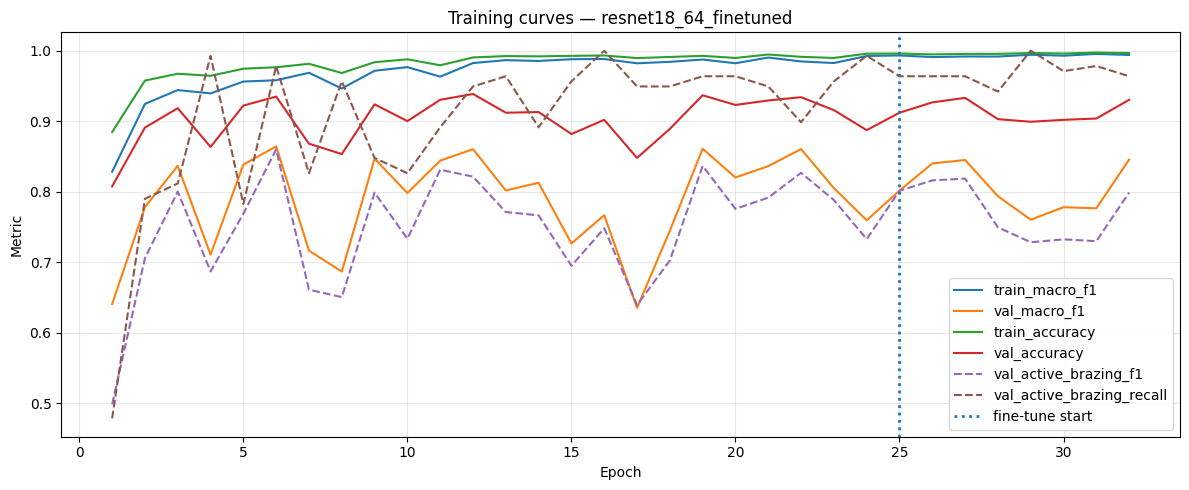

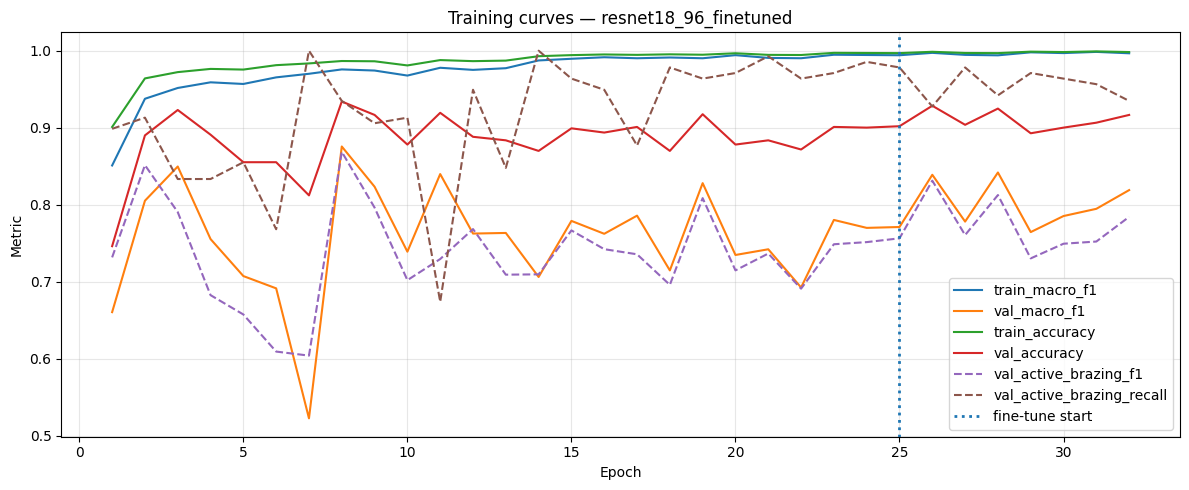

In [42]:
def plot_finetune_history(history_df, run_name):
    plt.figure(figsize=(12, 5))

    plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="train_macro_f1")
    plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="val_macro_f1")
    plt.plot(history_df["epoch"], history_df["train_accuracy"], label="train_accuracy")
    plt.plot(history_df["epoch"], history_df["val_accuracy"], label="val_accuracy")

    if "val_active_brazing_f1" in history_df.columns:
        plt.plot(
            history_df["epoch"],
            history_df["val_active_brazing_f1"],
            label="val_active_brazing_f1",
            linestyle="--",
        )

    if "val_active_brazing_recall" in history_df.columns:
        plt.plot(
            history_df["epoch"],
            history_df["val_active_brazing_recall"],
            label="val_active_brazing_recall",
            linestyle="--",
        )

    if "phase" in history_df.columns:
        finetune_start = history_df[history_df["phase"] == "finetune"]["epoch"].min()
        if not pd.isna(finetune_start):
            plt.axvline(
                finetune_start,
                linestyle=":",
                linewidth=2,
                label="fine-tune start",
            )

    plt.title(f"Training curves — {run_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_path = FIGURES_DIR / f"{run_name}_finetuned_training_curves.png"
    plt.savefig(output_path, dpi=160)
    plt.show()


for image_size, exp in FINE_TUNED_EXPERIMENTS.items():
    plot_finetune_history(
        exp["history"],
        run_name=f"resnet18_{image_size}_finetuned",
    )

### comparison

In [43]:
finetune_validation_rows = []

for image_size, exp in FINE_TUNED_EXPERIMENTS.items():
    history_df = exp["history"]
    best_row = history_df.loc[history_df["val_macro_f1"].idxmax()]

    finetune_validation_rows.append({
        "model": "resnet18",
        "image_size": image_size,
        "best_val_macro_f1": best_row["val_macro_f1"],
        "best_val_accuracy": best_row["val_accuracy"],
        "best_val_active_brazing_f1": best_row["val_active_brazing_f1"],
        "best_val_active_brazing_recall": best_row["val_active_brazing_recall"],
        "best_epoch": int(best_row["epoch"]),
        "checkpoint": str(exp["checkpoint"]),
    })

finetune_validation_comparison_df = pd.DataFrame(finetune_validation_rows).sort_values(
    "best_val_macro_f1",
    ascending=False,
)

finetune_validation_comparison_df

,model,image_size,best_val_macro_f1,best_val_accuracy,best_val_active_brazing_f1,best_val_active_brazing_recall,best_epoch,checkpoint
1,resnet18,96,0.875587,0.934005,0.868687,0.934783,8,models/checkpoints/resnet_input_size_cpu/resne...
0,resnet18,64,0.864217,0.934922,0.859873,0.978261,6,models/checkpoints/resnet_input_size_cpu/resne...


### nitial vs fine-tuned

In [44]:
initial_validation_comparison_df = validation_comparison_df.copy()
initial_validation_comparison_df["stage"] = "initial"

finetune_validation_tmp = finetune_validation_comparison_df.copy()
finetune_validation_tmp["stage"] = "finetuned"

validation_before_after_df = pd.concat(
    [initial_validation_comparison_df, finetune_validation_tmp],
    ignore_index=True,
)

validation_before_after_df = validation_before_after_df.sort_values(
    ["image_size", "stage"]
)

validation_before_after_df

,model,image_size,best_val_macro_f1,best_val_accuracy,best_val_active_brazing_f1,best_val_active_brazing_recall,checkpoint,stage,best_epoch
4,resnet18,64,0.864217,0.934922,0.859873,0.978261,models/checkpoints/resnet_input_size_cpu/resne...,finetuned,6.0
1,resnet18,64,0.864217,0.934922,0.859873,0.978261,models/checkpoints/resnet_input_size_cpu/resne...,initial,NaN
3,resnet18,96,0.875587,0.934005,0.868687,0.934783,models/checkpoints/resnet_input_size_cpu/resne...,finetuned,8.0
0,resnet18,96,0.875587,0.934005,0.868687,0.934783,models/checkpoints/resnet_input_size_cpu/resne...,initial,NaN
2,resnet18,128,0.863339,0.934005,0.882562,0.898551,models/checkpoints/resnet_input_size_cpu/resne...,initial,NaN


### test evaluation

Test — ResNet18 64x64 fine-tuned
--------------------------------------------------------------------------------
accuracy:    0.9174
macro_f1:    0.8328
weighted_f1: 0.9128

                      precision    recall  f1-score   support

inactive_preparation     0.9979    0.9690    0.9833      1000
     flux_activation     0.7262    0.8841    0.7974       138
      active_brazing     0.8621    0.5102    0.6410       196
       stabilization     0.8344    1.0000    0.9097       398

            accuracy                         0.9174      1732
           macro avg     0.8551    0.8408    0.8328      1732
        weighted avg     0.9233    0.9174    0.9128      1732



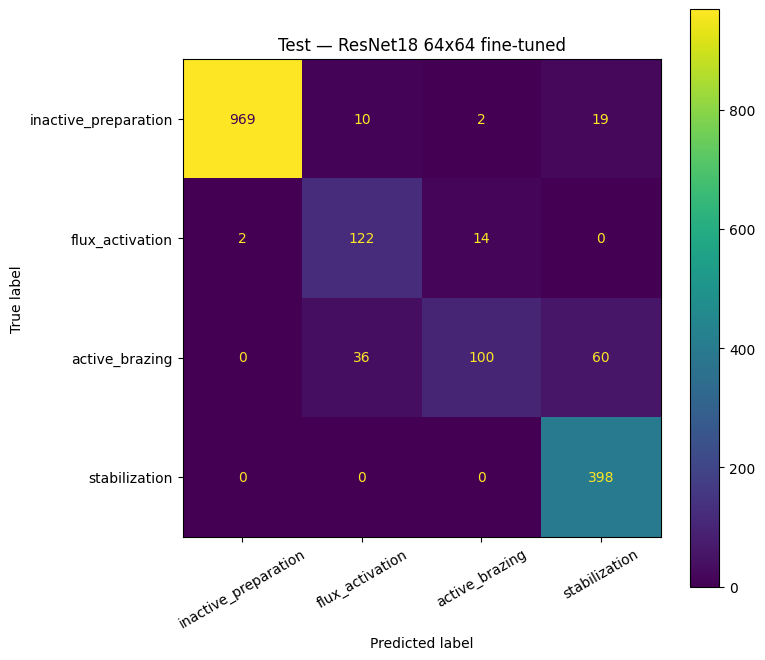

Test — ResNet18 96x96 fine-tuned
--------------------------------------------------------------------------------
accuracy:    0.8458
macro_f1:    0.7484
weighted_f1: 0.8584

                      precision    recall  f1-score   support

inactive_preparation     0.9988    0.8640    0.9265      1000
     flux_activation     0.3902    0.9783    0.5579       138
      active_brazing     0.8600    0.4388    0.5811       196
       stabilization     0.9026    0.9548    0.9280       398

            accuracy                         0.8458      1732
           macro avg     0.7879    0.8090    0.7484      1732
        weighted avg     0.9125    0.8458    0.8584      1732



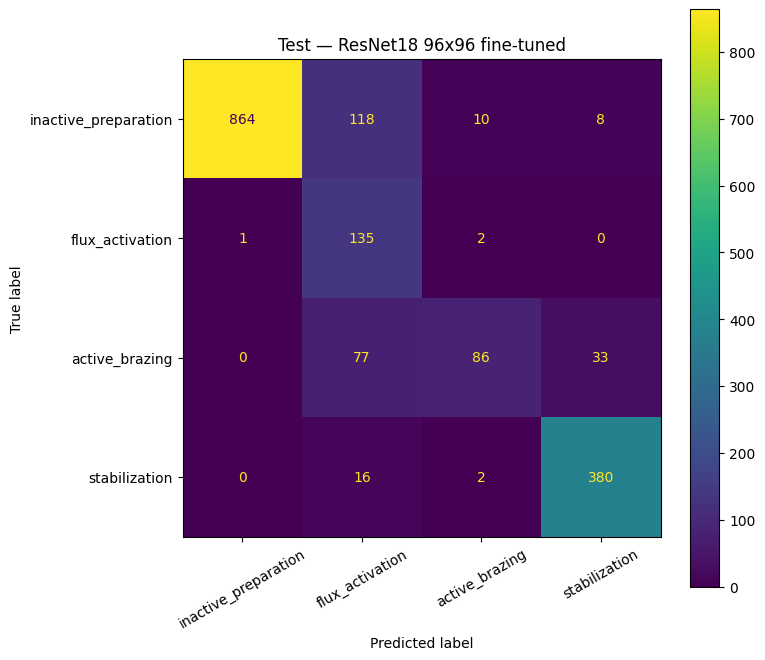

,model,image_size,accuracy,macro_f1,weighted_f1,active_brazing_precision,active_brazing_recall,active_brazing_f1,checkpoint
0,resnet18,64,0.917436,0.832846,0.912820,0.862069,0.510204,0.641026,models/checkpoints/resnet_input_size_cpu/resne...
1,resnet18,96,0.845843,0.748359,0.858398,0.860000,0.438776,0.581081,models/checkpoints/resnet_input_size_cpu/resne...


In [45]:
finetune_test_rows = []
finetune_test_predictions = {}

for image_size, exp in FINE_TUNED_EXPERIMENTS.items():
    model = exp["model"]
    test_loader = exp["test_loader"]

    pred_df = predict_loader(model, test_loader)

    metrics = evaluate_predictions(
        pred_df,
        title=f"Test — ResNet18 {image_size}x{image_size} fine-tuned",
    )

    finetune_test_predictions[image_size] = pred_df

    pred_df.to_csv(
        REPORTS_DIR / f"resnet18_{image_size}_finetuned_test_predictions.csv",
        index=False,
    )

    finetune_test_rows.append({
        "model": "resnet18",
        "image_size": image_size,
        **{k: v for k, v in metrics.items() if k != "confusion_matrix"},
        "checkpoint": str(exp["checkpoint"]),
    })

finetune_test_comparison_df = pd.DataFrame(finetune_test_rows).sort_values(
    "macro_f1",
    ascending=False,
)

finetune_test_comparison_df

In [46]:
finetune_test_comparison_df.to_csv(
    REPORTS_DIR / "resnet_input_size_finetuned_test_comparison.csv",
    index=False,
)

### initial vs fine-tuned by test

In [47]:
initial_test_comparison_df = test_comparison_df.copy()
initial_test_comparison_df["stage"] = "initial"

finetune_test_tmp = finetune_test_comparison_df.copy()
finetune_test_tmp["stage"] = "finetuned"

test_before_after_df = pd.concat(
    [initial_test_comparison_df, finetune_test_tmp],
    ignore_index=True,
)

test_before_after_df = test_before_after_df.sort_values(
    ["image_size", "stage"]
)

test_before_after_df

,model,image_size,accuracy,macro_f1,weighted_f1,active_brazing_precision,active_brazing_recall,active_brazing_f1,checkpoint,stage
3,resnet18,64,0.917436,0.832846,0.912820,0.862069,0.510204,0.641026,models/checkpoints/resnet_input_size_cpu/resne...,finetuned
0,resnet18,64,0.898961,0.796747,0.903250,0.737179,0.586735,0.653409,models/checkpoints/resnet_input_size_cpu/resne...,initial
4,resnet18,96,0.845843,0.748359,0.858398,0.860000,0.438776,0.581081,models/checkpoints/resnet_input_size_cpu/resne...,finetuned
1,resnet18,96,0.857968,0.773930,0.871450,0.703488,0.617347,0.657609,models/checkpoints/resnet_input_size_cpu/resne...,initial
2,resnet18,128,0.833141,0.755925,0.849971,0.724138,0.535714,0.615836,models/checkpoints/resnet_input_size_cpu/resne...,initial


### error pairs

In [48]:
for image_size, pred_df in finetune_test_predictions.items():
    print(f"Error pairs — ResNet18 {image_size} fine-tuned")
    display(get_error_pairs(pred_df).head(20))

Error pairs — ResNet18 64 fine-tuned


,stage_name,pred_stage_name,count
1,active_brazing,stabilization,60
0,active_brazing,flux_activation,36
6,inactive_preparation,stabilization,19
2,flux_activation,active_brazing,14
5,inactive_preparation,flux_activation,10
4,inactive_preparation,active_brazing,2
3,flux_activation,inactive_preparation,2


Error pairs — ResNet18 96 fine-tuned


,stage_name,pred_stage_name,count
5,inactive_preparation,flux_activation,118
0,active_brazing,flux_activation,77
1,active_brazing,stabilization,33
8,stabilization,flux_activation,16
4,inactive_preparation,active_brazing,10
6,inactive_preparation,stabilization,8
2,flux_activation,active_brazing,2
7,stabilization,active_brazing,2
3,flux_activation,inactive_preparation,1


### timeline

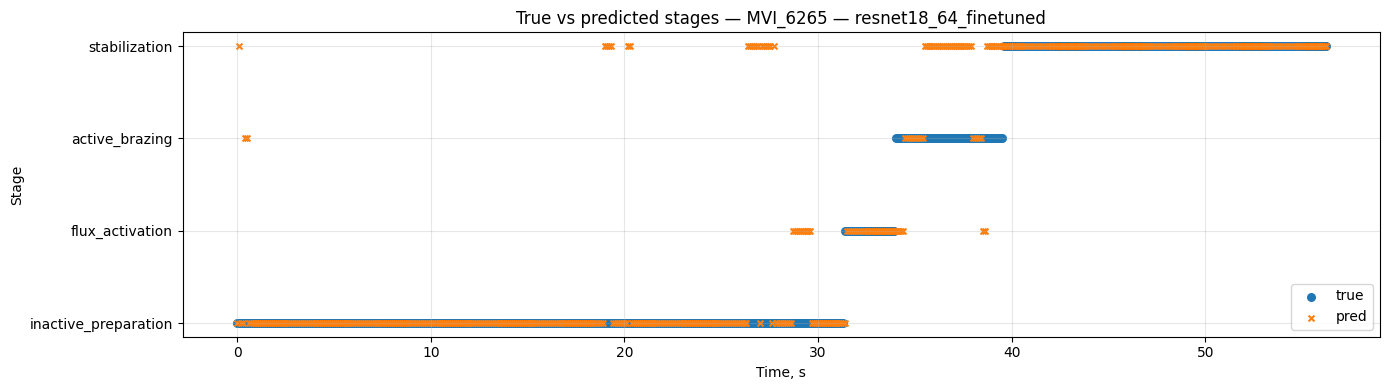

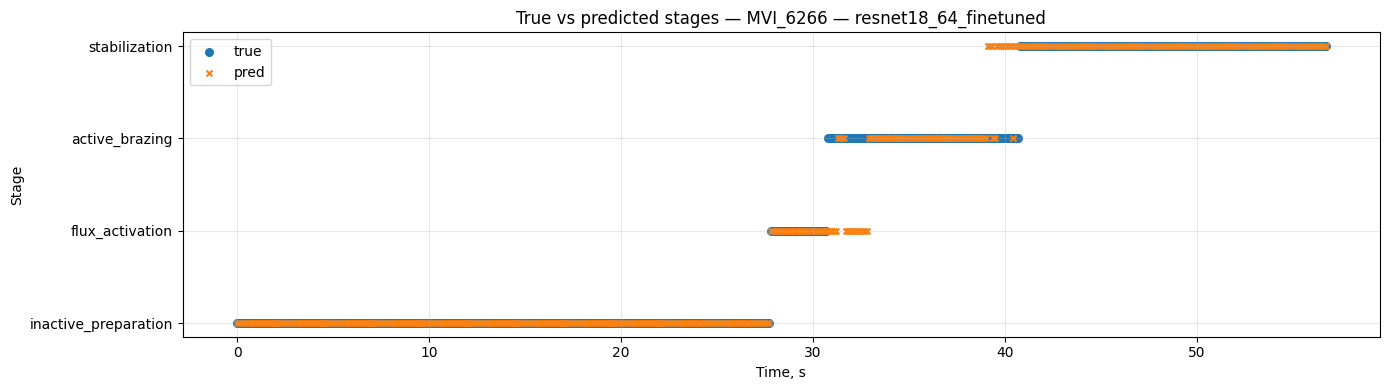

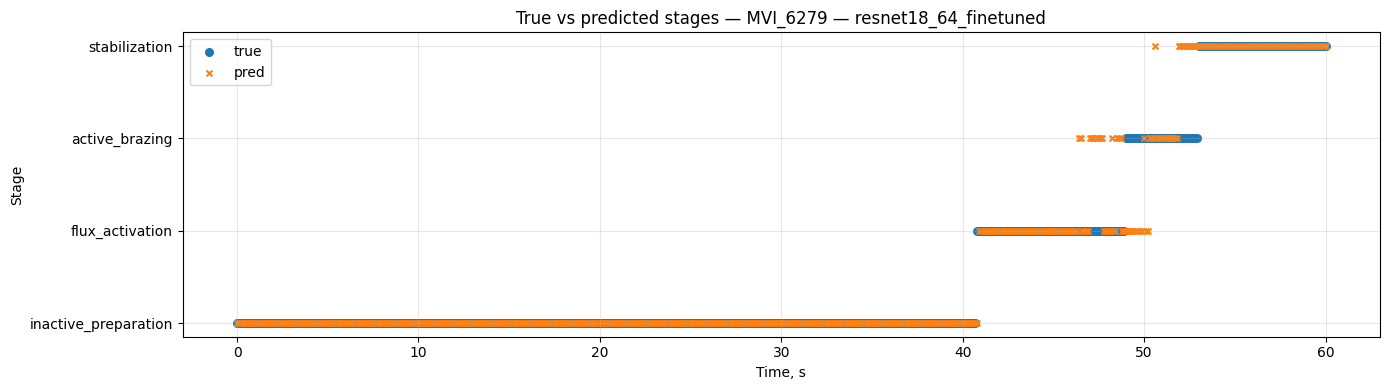

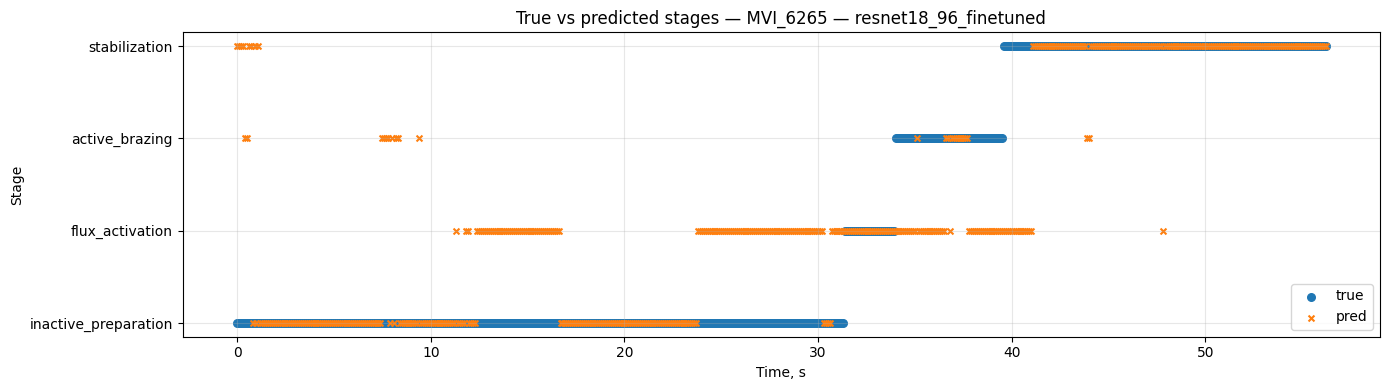

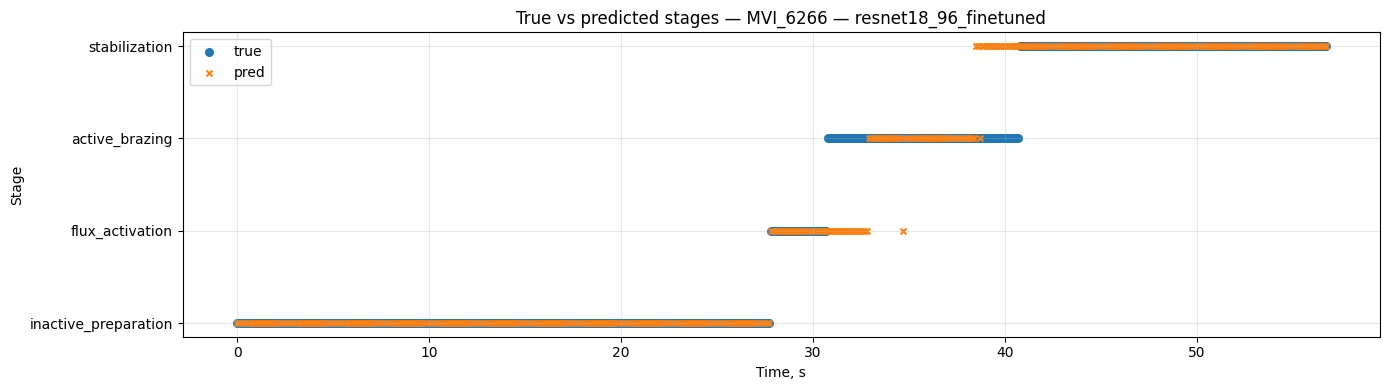

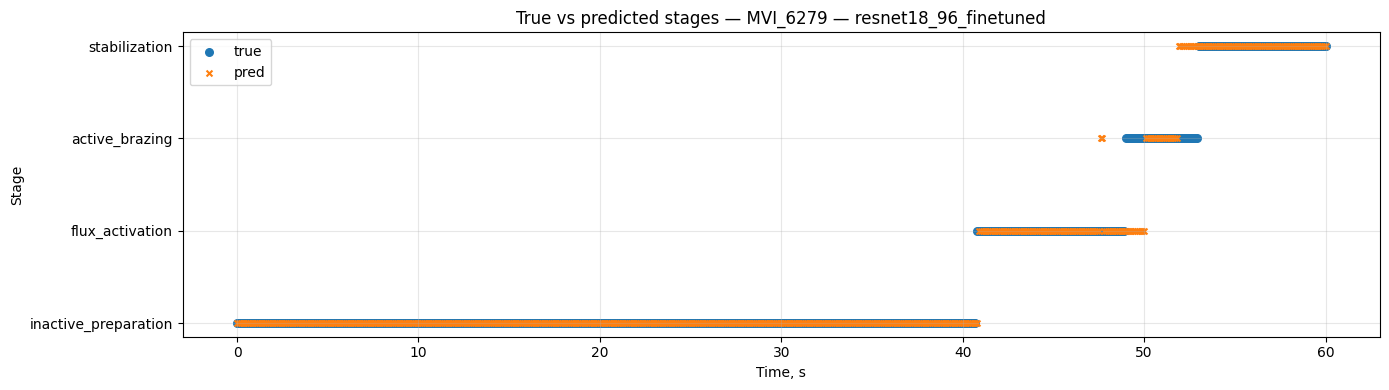

In [49]:
for image_size, pred_df in finetune_test_predictions.items():
    for video_id in sorted(pred_df["video_id"].unique()):
        plot_predictions_for_video(
            pred_df,
            video_id=video_id,
            run_name=f"resnet18_{image_size}_finetuned",
        )

## quality vs latency

In [59]:
latency_rows = [
    {
        "model": "resnet18",
        "image_size": 128,
        "cpu_total_mean_ms": 43.763,
        "cpu_total_p95_ms": 65.261,
        "cpu_model_mean_ms": 37.654,
        "passes_50ms_p95": False,
        "note": "Existing CPU benchmark, 128x128",
    },
    {
        "model": "resnet18",
        "image_size": 96,
        "cpu_total_mean_ms": 36.222,
        "cpu_total_p95_ms": 53.788,
        "cpu_model_mean_ms": 30.523,
        "passes_50ms_p95": False,
        "note": "Existing CPU benchmark, 96x96",
    },
    {
        "model": "resnet18",
        "image_size": 64,
        "cpu_total_mean_ms": 26.155,
        "cpu_total_p95_ms": 39.767,
        "cpu_model_mean_ms": 20.492,
        "passes_50ms_p95": True,
        "note": "Existing CPU benchmark, 64x64",
    },
]

latency_df = pd.DataFrame(latency_rows)
latency_df

,model,image_size,cpu_total_mean_ms,cpu_total_p95_ms,cpu_model_mean_ms,passes_50ms_p95,note
0,resnet18,128,43.763,65.261,37.654,False,"Existing CPU benchmark, 128x128"
1,resnet18,96,36.222,53.788,30.523,False,"Existing CPU benchmark, 96x96"
2,resnet18,64,26.155,39.767,20.492,True,"Existing CPU benchmark, 64x64"


In [60]:
test_comparison_df

,model,image_size,accuracy,macro_f1,weighted_f1,active_brazing_precision,active_brazing_recall,active_brazing_f1,checkpoint
2,resnet18,64,0.898961,0.796747,0.903250,0.737179,0.586735,0.653409,models/checkpoints/resnet_input_size_cpu/resne...
1,resnet18,96,0.857968,0.773930,0.871450,0.703488,0.617347,0.657609,models/checkpoints/resnet_input_size_cpu/resne...
0,resnet18,128,0.833141,0.755925,0.849971,0.724138,0.535714,0.615836,models/checkpoints/resnet_input_size_cpu/resne...


In [61]:
quality_latency_df = test_before_after_df.merge(
    latency_df,
    on=["model", "image_size"],
    how="left",
)

quality_latency_df

,model,image_size,accuracy,macro_f1,weighted_f1,active_brazing_precision,active_brazing_recall,active_brazing_f1,checkpoint,stage,cpu_total_mean_ms,cpu_total_p95_ms,cpu_model_mean_ms,passes_50ms_p95,note
0,resnet18,64,0.917436,0.832846,0.912820,0.862069,0.510204,0.641026,models/checkpoints/resnet_input_size_cpu/resne...,finetuned,26.155,39.767,20.492,True,"Existing CPU benchmark, 64x64"
1,resnet18,64,0.898961,0.796747,0.903250,0.737179,0.586735,0.653409,models/checkpoints/resnet_input_size_cpu/resne...,initial,26.155,39.767,20.492,True,"Existing CPU benchmark, 64x64"
2,resnet18,96,0.845843,0.748359,0.858398,0.860000,0.438776,0.581081,models/checkpoints/resnet_input_size_cpu/resne...,finetuned,36.222,53.788,30.523,False,"Existing CPU benchmark, 96x96"
3,resnet18,96,0.857968,0.773930,0.871450,0.703488,0.617347,0.657609,models/checkpoints/resnet_input_size_cpu/resne...,initial,36.222,53.788,30.523,False,"Existing CPU benchmark, 96x96"
4,resnet18,128,0.833141,0.755925,0.849971,0.724138,0.535714,0.615836,models/checkpoints/resnet_input_size_cpu/resne...,initial,43.763,65.261,37.654,False,"Existing CPU benchmark, 128x128"


In [62]:
quality_latency_df.to_csv(
    REPORTS_DIR / "resnet_quality_latency_comparison.csv",
    index=False,
)

# results

In [63]:
!cp -r "$CHECKPOINTS_DIR"/. "$DRIVE_CHECKPOINTS_DIR"/

В результате эксперимента с уменьшением входного разрешения ResNet18 было показано, что вариант `64×64` удовлетворяет ограничению 50 мс/кадр на CPU и при этом сохраняет приемлемое качество классификации стадий. После fine-tune модель `ResNet18 64×64` достигла accuracy = 0.9174 и macro-F1 = 0.8328 при p95 задержки около 39.8 мс. При этом качество распознавания стадии `active_brazing` осталось ограничивающим фактором: fine-tune повысил общую точность, но снизил recall этой стадии. Варианты `96×96` и `128×128` оказались менее предпочтительными, поскольку уступили `64×64` по качеству и/или не удовлетворили ограничению p95 < 50 мс.